# Flow pattern at Ri=1

Ra=10000.0, Jt=1.000, Jc=1.000, Nu=1.000, Sh=1.000, Gamma=0.020
Ra=15000.0, Jt=1.075, Jc=1.285, Nu=1.075, Sh=1.284, Gamma=0.024
Ra=20000.0, Jt=1.280, Jc=1.655, Nu=1.280, Sh=1.654, Gamma=0.026
Ra=30000.0, Jt=1.821, Jc=2.800, Nu=1.821, Sh=2.797, Gamma=0.031
Ra=40000.0, Jt=1.515, Jc=2.674, Nu=1.512, Sh=2.640, Gamma=0.035
Ra=50000.0, Jt=1.555, Jc=2.952, Nu=1.550, Sh=2.864, Gamma=0.037
Ra=100000.0, Jt=1.711, Jc=3.730, Nu=1.701, Sh=3.744, Gamma=0.044
Ra=150000.0, Jt=1.977, Jc=3.628, Nu=1.977, Sh=3.671, Gamma=0.037
Ra=200000.0, Jt=2.221, Jc=3.680, Nu=2.221, Sh=3.751, Gamma=0.034
Ra=300000.0, Jt=2.514, Jc=4.407, Nu=2.517, Sh=4.428, Gamma=0.035
Ra=500000.0, Jt=2.839, Jc=5.097, Nu=2.846, Sh=5.535, Gamma=0.039
Ra=1000000.0, Jt=3.478, Jc=6.579, Nu=3.480, Sh=7.782, Gamma=0.045


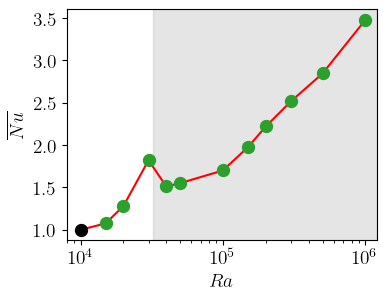

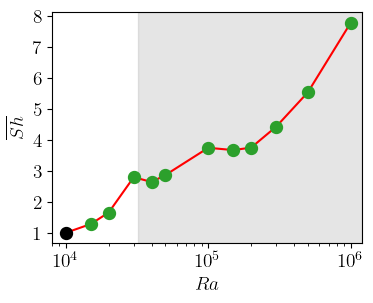

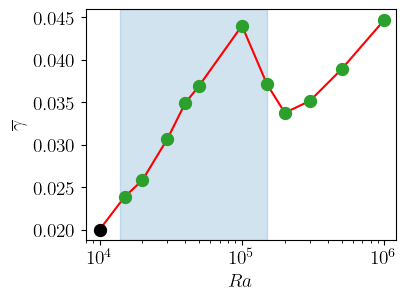

In [1]:
from func import *
def get_mean_data(path,start=0,end=-1):
    [_,Jt]=readdata(path,16)
    [_,Nu]=readdata(path,17)
    [_,Jc]=readdata(path,21)
    [_,Sh]=readdata(path,22)
    mean_Jt=np.mean(Jt[start:end])
    mean_Jc=np.mean(Jc[start:end])
    mean_Nu=np.mean(Nu[start:end])
    mean_Sh=np.mean(Sh[start:end])
    return mean_Jt,mean_Jc,mean_Nu,mean_Sh

Ra_list=[]
Jt_list=[]
Jc_list=[]
Nu_list=[]
Sh_list=[]

Lambda = 2
tau = 0.01

def append_data(Ra, path, start, end):
    Jt,Jc,Nu,Sh = get_mean_data(path,start,end)
    Ra_list.append(Ra)
    Jt_list.append(Jt)
    Jc_list.append(Jc)
    Nu_list.append(Nu)
    Sh_list.append(Sh)


append_data(10000,"Data/DNS/Flow_structure_classification/Ra10000/energy.asc",5000,-1)

append_data(15000,"Data/DNS/Flow_structure_classification/Ra15000/energy.asc",5000,-1)

append_data(20000,"Data/DNS/Flow_structure_classification/Ra20000/energy.asc",-3000,-1)

append_data(30000,"Data/DNS/Flow_structure_classification/Ra30000/energy.asc",-3000,-1)

append_data(40000,"Data/DNS/Flow_structure_classification/Ra40000/energy.asc",-8000,-1)

append_data(50000,"Data/DNS/Flow_structure_classification/Ra50000/energy.asc",-2500,-1)

append_data(100000,"Data/DNS/Flow_structure_classification/Ra100000/energy.asc",-4000,-1)

append_data(150000,"Data/DNS/Flow_structure_classification/Ra150000/energy.asc",-4000,-1)

append_data(200000,"Data/DNS/Flow_structure_classification/Ra200000/energy.asc",-4000,-1)

append_data(300000,"Data/DNS/Flow_structure_classification/Ra300000/energy.asc",-4000,-1)

append_data(500000,"Data/DNS/Flow_structure_classification/Ra500000/energy.asc",-4000,-1)

append_data(1000000,"Data/DNS/Flow_structure_classification/Ra1000000/energy.asc",-4000,-1)


Ra_arr = np.array(Ra_list)
Jt_arr = np.array(Jt_list)
Jc_arr = np.array(Jc_list)
Sh_arr = np.array(Sh_list)
Nu_arr = np.array(Nu_list)

plot_Nu=True
plot_Sh=True
plot_flux_ratio=True

# print("Ra:",Ra_arr.T)
# print("Nu:",Nu_arr)
# print("Sh:",Sh_arr)
# print("Gamma:",Lambda*tau*Sh_arr/Nu_arr)

# print(np.array([Ra_arr.T,Nu_arr.T,Sh_arr.T,(Lambda*tau*Sh_arr/Nu_arr).T]))


for i in range(len(Ra_arr)):
    print(f"Ra={Ra_arr[i]:.1f}, Jt={Jt_arr[i]:.3f}, Jc={Jc_arr[i]:.3f}, Nu={Nu_arr[i]:.3f}, Sh={Sh_arr[i]:.3f}, Gamma={Lambda*tau*Sh_arr[i]/Nu_arr[i]:.3f}")


if plot_Nu:
    plt.figure(figsize=(4, 3))
    plt.plot(Ra_arr,Nu_arr,'r-',zorder=1)
    plt.scatter(Ra_arr[0],Nu_arr[0],color='k',linewidths=2.5,s=50,marker='o',zorder=2)
    # plt.scatter(Ra_arr[1:7],Nu_arr[1:7],color='tab:green',facecolors='none',linewidths=2.5,s=50,marker='o',zorder=2)
    plt.scatter(Ra_arr[1:],Nu_arr[1:],color='tab:green',linewidths=2.5,s=50,marker='o',zorder=2)
    plt.xscale("log")
    xmin, xmax = plt.xlim([8000, 1.2e6])
    plt.axvspan(32000, xmax, color='grey', alpha=0.2, zorder=0)
    plt.ylabel(r'$\overline{Nu}$', fontsize=14)
    plt.xlabel(r'$Ra$', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig('Data/DNS/Flow_structure_classification/Nu.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
if plot_Sh:
    plt.figure(figsize=(4, 3))
    plt.plot(Ra_arr,Sh_arr,'r-',zorder=1)
    plt.scatter(Ra_arr[0],Sh_arr[0],color='k',linewidths=2.5,s=50,marker='o',zorder=2)
    # plt.scatter(Ra_arr[1:7],Sh_arr[1:7],color='tab:green',facecolors='none',linewidths=2.5,s=50,marker='o',zorder=2)
    plt.scatter(Ra_arr[1:],Sh_arr[1:],color='tab:green',linewidths=2.5,s=50,marker='o',zorder=2)
    plt.xscale("log")
    xmin, xmax = plt.xlim([8000, 1.2e6])
    plt.axvspan(32000, xmax, color='grey', alpha=0.2, zorder=0)
    plt.ylabel(r'$\overline{Sh}$', fontsize=14)
    plt.xlabel(r'$Ra$', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig('Data/DNS/Flow_structure_classification/Sh.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
if plot_flux_ratio:
    plt.figure(figsize=(4, 3))
    plt.plot(Ra_arr,Lambda*tau*Sh_arr/Nu_arr,'r-',zorder=1)
    plt.scatter(Ra_arr[0],Lambda*tau*Sh_arr[0]/Nu_arr[0],color='k',linewidths=2.5,s=50,marker='o',zorder=2)
    # plt.scatter(Ra_arr[1:7],Lambda*tau*Sh_arr[1:7]/Nu_arr[1:7],color='tab:green',facecolors='none',linewidths=2.5,s=50,marker='o',zorder=2)
    plt.scatter(Ra_arr[1:],Lambda*tau*Sh_arr[1:]/Nu_arr[1:],color='tab:green',linewidths=2.5,s=50,marker='o',zorder=2)
    plt.xscale("log")
    xmin, xmax = plt.xlim([8000, 1.2e6])
    plt.axvspan(14000, 150000, color='tab:blue', alpha=0.2, zorder=0)
    plt.ylabel(r'$\overline{\gamma}$', fontsize=14)
    plt.xlabel(r'$Ra$', fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig('Data/DNS/Flow_structure_classification/FluxRatio.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()



# Check contribution of shear production to energy balance.
To confirm the shear-influenced regime within the present parameter regime, we have computed the contributions of shear production and buoyant energy input to the kinetic energy balance. By taking the inner product between $\boldsymbol{U}$ and \eqref{eq.sddc_nondimensional.momentum} and then taking the volume average ($\langle \cdot \rangle$) over the entire domain, the kinetic energy equation can be determined by
$$\frac{1}{2} \frac{\partial}{\partial t} \left\langle \boldsymbol{U}^2 \right\rangle = \sqrt{\frac{Pr}{Ra}} \tau_w U_w + \left\langle (T-\Lambda S)w \right\rangle - \sqrt{\frac{Pr}{Ra}} \left\langle (\nabla \times \boldsymbol{U})^2 \right\rangle = I_w + I_b - D,$$

where $I_w$ and $I_b$ are the rates of energy input from the walls \citep{halcrow2008charting} and buoyancy forces \citep{reetz2019turbulent}. In equation \eqref{eq:energy_balance}, $D$ is the viscous dissipation, and $\tau_w$ is the wall-shear stress

$$\tau_w := 1 + \frac{1}{2L_x L_y} \int_{0}^{L_x} \int_{0}^{L_y} \left( \left.\frac{\partial u}{\partial z} \right|_{z=-0.5} + \left.\frac{\partial u}{\partial z} \right|_{z=0.5}\right) \,dx \,dy.$$

After performing a time average of \eqref{eq:energy_balance}, all equilibrium states and statistically steady states should satisfy $\overline{I}_w + \overline{I}_b = \overline{D}$

In [2]:
from func import *
def get_mean_data(path,start=0,end=-1):
    [_,Jt]=readdata(path,16)
    [_,Nu]=readdata(path,17)
    [_,Jc]=readdata(path,21)
    [_,Sh]=readdata(path,22)
    [_,D]=readdata(path,4)
    [_,I]=readdata(path,23)
    mean_Jt=np.mean(Jt[start:end])
    mean_Jc=np.mean(Jc[start:end])
    mean_Nu=np.mean(Nu[start:end])
    mean_Sh=np.mean(Sh[start:end])
    mean_I=np.mean(I[start:end], axis=0)
    mean_D=np.mean(D[start:end], axis=0)
    return mean_Jt,mean_Jc,mean_Nu,mean_Sh,mean_D,mean_I

Ra_list=[]
Jt_list=[]
Jc_list=[]
Nu_list=[]
Sh_list=[]
I_list=[]
D_list=[]

Lambda = 2
tau = 0.01

def append_data(Ra, path, start, end):
    Jt,Jc,Nu,Sh,D,I = get_mean_data(path,start,end)
    Ra_list.append(Ra)
    Jt_list.append(Jt)
    Jc_list.append(Jc)
    Nu_list.append(Nu)
    Sh_list.append(Sh)
    D_list.append(D)
    I_list.append(I)


append_data(10000,"Data/DNS/Flow_structure_classification/Ra10000/energy.asc",5000,-1)

append_data(15000,"Data/DNS/Flow_structure_classification/Ra15000/energy.asc",5000,-1)

append_data(20000,"Data/DNS/Flow_structure_classification/Ra20000/energy.asc",-3000,-1)

append_data(30000,"Data/DNS/Flow_structure_classification/Ra30000/energy.asc",-3000,-1)

append_data(40000,"Data/DNS/Flow_structure_classification/Ra40000/energy.asc",-8000,-1)

append_data(50000,"Data/DNS/Flow_structure_classification/Ra50000/energy.asc",-2500,-1)

append_data(100000,"Data/DNS/Flow_structure_classification/Ra100000/energy.asc",-4000,-1)

append_data(150000,"Data/DNS/Flow_structure_classification/Ra150000/energy.asc",-4000,-1)

append_data(200000,"Data/DNS/Flow_structure_classification/Ra200000/energy.asc",-4000,-1)

append_data(300000,"Data/DNS/Flow_structure_classification/Ra300000/energy.asc",-4000,-1)

append_data(500000,"Data/DNS/Flow_structure_classification/Ra500000/energy.asc",-4000,-1)

append_data(1000000,"Data/DNS/Flow_structure_classification/Ra1000000/energy.asc",-4000,-1)

Ra_arr = np.array(Ra_list)
Jt_arr = np.array(Jt_list)
Jc_arr = np.array(Jc_list)
Sh_arr = np.array(Sh_list)
Nu_arr = np.array(Nu_list)
D_arr = np.array(D_list)
I_arr = np.array(I_list)


for i in range(len(Ra_arr)):
    print(f"Ra={Ra_arr[i]:.1f}, I={I_arr[i]:.6f} contribute {I_arr[i]/D_arr[i]:.6f}, D={D_arr[i]:.5f}, D-I={D_arr[i]-I_arr[i]:.5f} contribute {(D_arr[i]-I_arr[i])/D_arr[i]:.6f}")

Ra=10000.0, I=-0.000000 contribute -0.000000, D=0.07851, D-I=0.07851 contribute 1.000000
Ra=15000.0, I=0.000215 contribute 0.003348, D=0.06434, D-I=0.06412 contribute 0.996652
Ra=20000.0, I=0.000715 contribute 0.012663, D=0.05643, D-I=0.05571 contribute 0.987337
Ra=30000.0, I=0.001713 contribute 0.223747, D=0.00766, D-I=0.00594 contribute 0.776253
Ra=40000.0, I=0.000907 contribute 0.022649, D=0.04006, D-I=0.03915 contribute 0.977351
Ra=50000.0, I=0.000870 contribute 0.115035, D=0.00756, D-I=0.00669 contribute 0.884965
Ra=100000.0, I=0.000779 contribute 0.030443, D=0.02557, D-I=0.02479 contribute 0.969557
Ra=150000.0, I=0.000901 contribute 0.042791, D=0.02106, D-I=0.02016 contribute 0.957209
Ra=200000.0, I=0.000985 contribute 0.053593, D=0.01838, D-I=0.01739 contribute 0.946407
Ra=300000.0, I=0.000999 contribute 0.066174, D=0.01510, D-I=0.01410 contribute 0.933826
Ra=500000.0, I=0.000938 contribute 0.079677, D=0.01178, D-I=0.01084 contribute 0.920323
Ra=1000000.0, I=0.000888 contribute 